# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

Text(0.5, 1.0, "Pokemon's HP in Correlation to Attack and Defense")

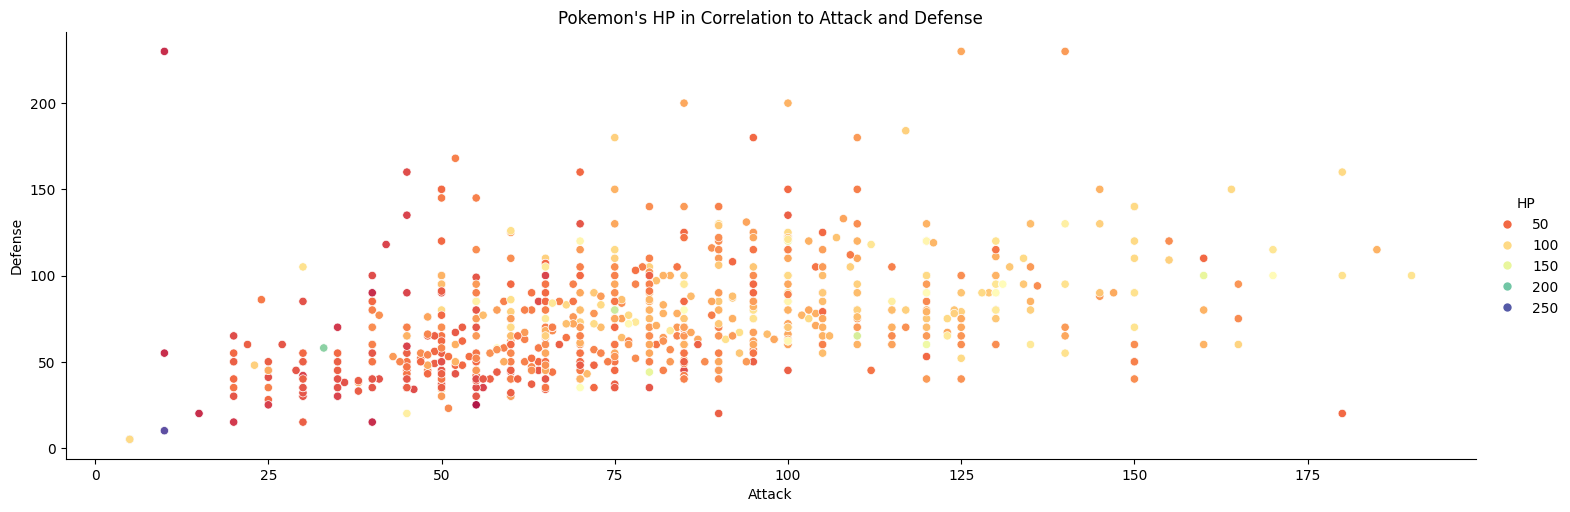

In [ ]:
# Your code here . . .

pokedex = pd.read_csv(fp)

sns.relplot(
    data=pokedex,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="Spectral",
    aspect=3.0
)

plt.title("Pokemon's HP in Correlation to Attack and Defense")

In [ ]:
# pokedex['#'].count()
pokedex.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   #           800 non-null    int64 
 1   Name        800 non-null    object
 2   Type 1      800 non-null    object
 3   Type 2      414 non-null    object
 4   Total       800 non-null    int64 
 5   HP          800 non-null    int64 
 6   Attack      800 non-null    int64 
 7   Defense     800 non-null    int64 
 8   Sp. Atk     800 non-null    int64 
 9   Sp. Def     800 non-null    int64 
 10  Speed       800 non-null    int64 
 11  Generation  800 non-null    int64 
 12  Legendary   800 non-null    bool  
dtypes: bool(1), int64(9), object(3)
memory usage: 75.9+ KB


### From the plot, I observed....
Results: There is no visible correlation between `Attack` and `Defense`. Higher `Attack` and `Defense` values do not meaningfully affect the hit points (`HP`) of Pokemons.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

Text(0.5, 1.0, 'Attack vs. Total for All Pokemon')

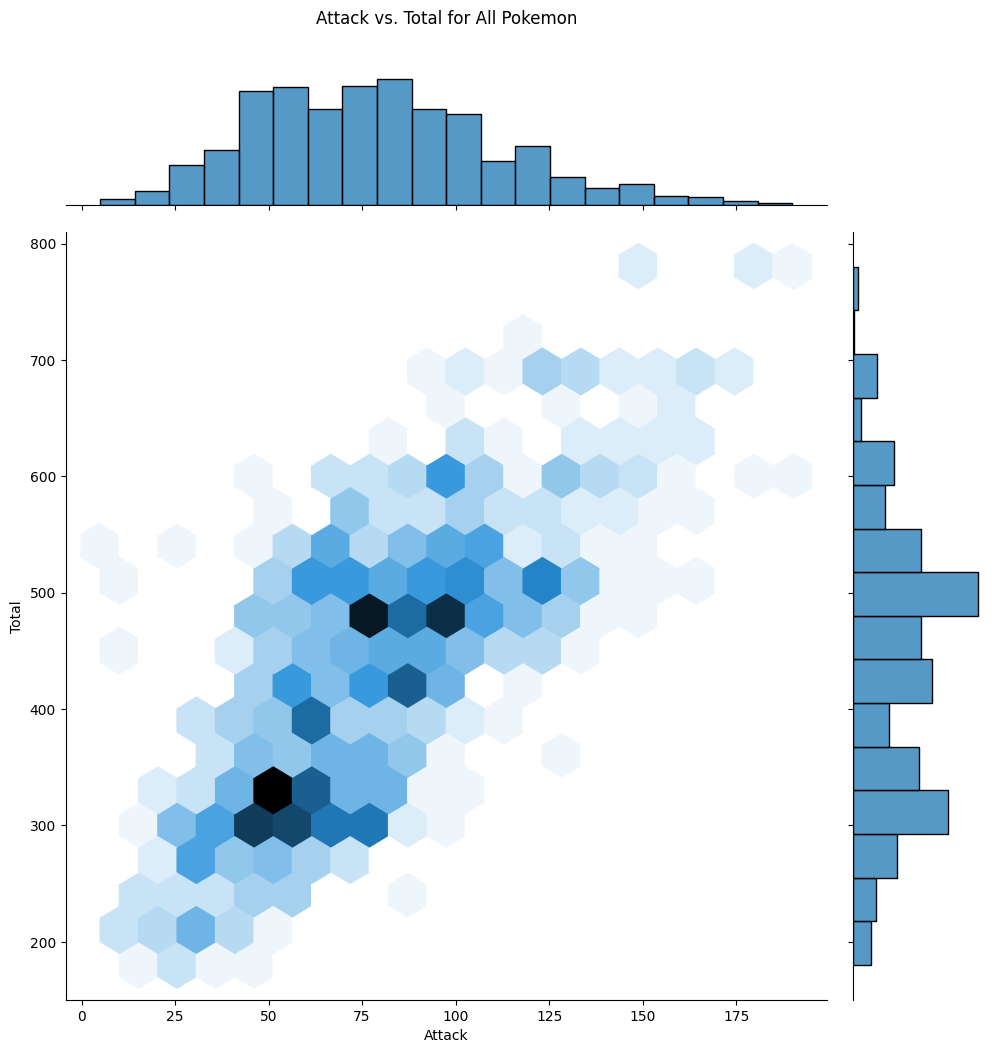

In [ ]:
# Your code here . . .
sns.jointplot(
    data=pokedex,
    x="Attack",
    y="Total",
    kind="hex",
    height=10,
    space=0.2
)

plt.title("Attack vs. Total for All Pokemon", pad=150)

# From the plot, I observed....
Results: There is a positive relationship between `Attack` and `Total` values, because `Total` is the sum of all stat values, which includes `Attack`. Additionally, the `Attack` value appears to consistently contribute to high `Total` values.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

Text(0.5, 1.05, 'Most Common Type 2 Pokemons')

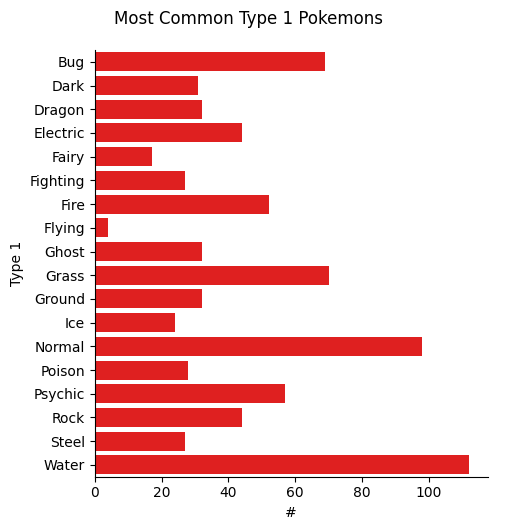

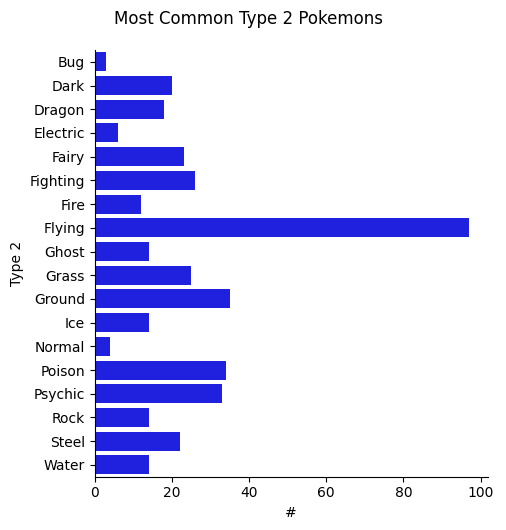

In [ ]:
t1_series = pokedex.groupby("Type 1")['#'].size()
t1_pokemon_count = pd.DataFrame(t1_series)
# type(t1_pokemon_count)

t2_series = pokedex.groupby("Type 2")['#'].size()
t2_pokemon_count = pd.DataFrame(t2_series)

# Your code here . . .
t1 = sns.catplot(
    data=t1_pokemon_count,
    x="#",
    y="Type 1",
    color="red",
    kind="bar"
)

t1.fig.suptitle("Most Common Type 1 Pokemons", y=1.05)

t2 = sns.catplot(
    data=t2_pokemon_count,
    x="#",
    y="Type 2",
    color="blue",
    kind="bar"
)

t2.fig.suptitle("Most Common Type 2 Pokemons", y=1.05)

# From the two categorical plots, I observed...
Results: The most common Type 1 Pokemon is Water, and the most common Type 2 Pokemon is Flying. On the other hand, the most rare Type 1 Pokemon is Flying, and the most rare Type 2 Pokemon is Bug.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

Your question(s) . . .

# Q4. Which Pokemon has the highest HP in the Pokedex?

Text(0.5, 1.0, "Pokemon's HP")

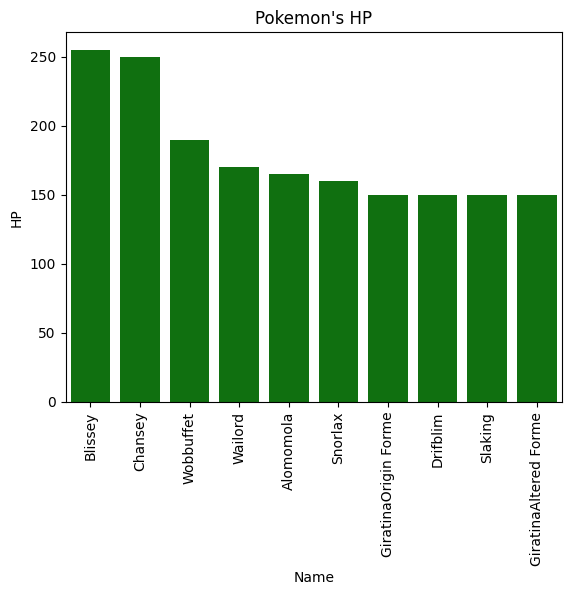

In [ ]:
# Your code here . . .
max_hp = sns.barplot(
    data=pokedex.sort_values(by="HP", ascending=False).head(10),
    x="Name",
    y="HP",
    color="green"
)

max_hp.set_xticks(range(10))
max_hp.set_xticklabels(max_hp.get_xticklabels(), rotation=90)

plt.title("Pokemon's HP")

# From the barplot, I observed...

Results: The Pokemon with the highest HP (up to Gen 6) is Blissey.

# Q5. How many legendaries are in each generation in the Pokedex?

Text(0.5, 1.0, 'Number of Legendaries in Each Generation')

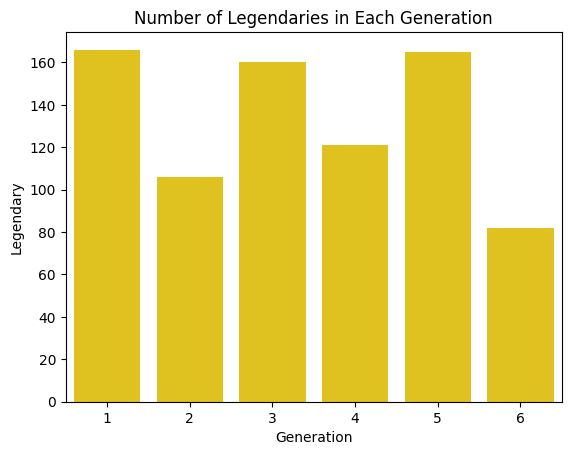

In [18]:
legend_count = pokedex.groupby("Generation")["Legendary"].size()
legend_count = pd.DataFrame(legend_count)

legend_plt = sns.barplot(
    data=legend_count,
    x="Generation",
    y="Legendary",
    color="gold"
)

plt.title("Number of Legendaries in Each Generation")

From the bar plot, Generations 1 and 5 appear to have the most number of legendary Pokemon, while Generation 6 has the least number.

# Q6. What is the correlation between a Pokemon's `Attack` and `Sp. Atk`?

Text(0.5, 1.0, "Correlation Between Pokemon's Attack and Special Attack Damage")

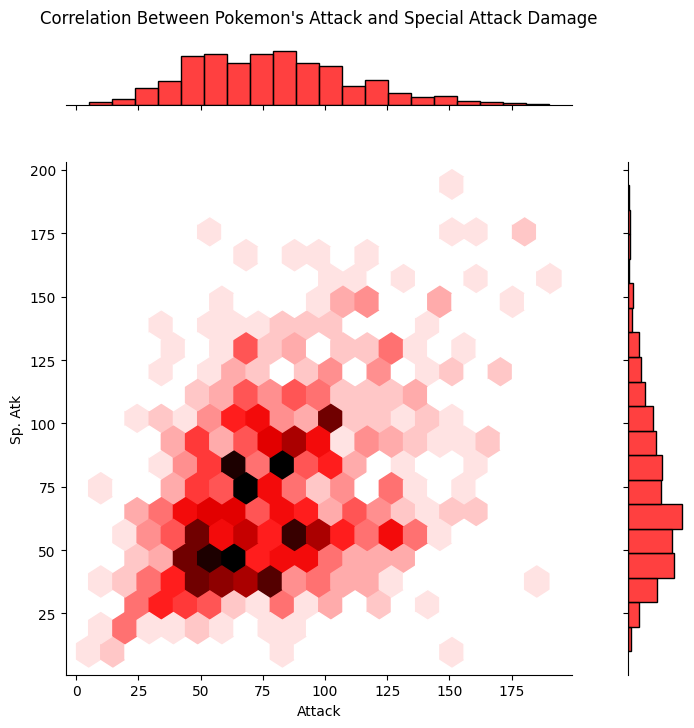

In [17]:
attack_rel = sns.jointplot(
    data=pokedex,
    x="Attack",
    y="Sp. Atk",
    kind="hex",
    height=7,
    space=1,
    color="red"
)

plt.title("Correlation Between Pokemon's Attack and Special Attack Damage", pad=100)

# From the hex plot, I observed...

Results: There appears to be a positive correlation between a Pokemon's `Attack` and `Sp. Atk` damages. Higher `Attack` base damage is strongly correlated with higher `Sp. Atk` base damage.